In [1]:
 import os, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


In [2]:
print("Corn/maize-related directories in /kaggle/input/:\n")
print(f"{'Count':>6}  Path")
print("-" * 100)

for root, dirs, files in os.walk("/kaggle/input"):
    for d in dirs:
        if "corn" in d.lower() or "maize" in d.lower():
            full = Path(root) / d
            n = sum(1 for f in full.iterdir()
                    if f.is_file() and f.suffix.lower() in {".jpg", ".jpeg", ".png"})
            if n > 0:
                tail = "/".join(full.parts[-4:])
                print(f"  {n:>5}  .../{tail}")

Corn/maize-related directories in /kaggle/input/:

 Count  Path
----------------------------------------------------------------------------------------------------
      4  .../nirmalsankalana/plantdoc-dataset/test/Corn_Gray_leaf_spot
     12  .../nirmalsankalana/plantdoc-dataset/test/Corn_leaf_blight
     10  .../nirmalsankalana/plantdoc-dataset/test/Corn_rust_leaf
     63  .../nirmalsankalana/plantdoc-dataset/train/Corn_Gray_leaf_spot
    182  .../nirmalsankalana/plantdoc-dataset/train/Corn_leaf_blight
    107  .../nirmalsankalana/plantdoc-dataset/train/Corn_rust_leaf
    985  .../abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___Northern_Leaf_Blight
    513  .../abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   1192  .../abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___Common_rust_
   1162  .../abdallahalidev/plantvillage-dataset/segmented/Corn_(maize)___healthy
    985  .../abdallahalidev/plantvillage-dataset

In [3]:
# Auto-discover roots
pv_candidates, pd_candidates = [], []
for root, dirs, files in os.walk("/kaggle/input"):
    for d in dirs:
        if d == "Corn_(maize)___healthy":
            pv_candidates.append(Path(root) / d)
        elif d == "Corn_rust_leaf":
            pd_candidates.append(Path(root) / d)

color_roots = [c.parent for c in pv_candidates if c.parent.name == "color"]
assert color_roots, "PlantVillage color/ not found"
PV_ROOT = color_roots[0]

pd_roots = {c.parent.parent for c in pd_candidates}
assert pd_roots, "PlantDoc root not found"
PD_ROOT = next(iter(pd_roots))

print(f"PV_ROOT = {PV_ROOT}")
print(f"PD_ROOT = {PD_ROOT}\n")

PV_CLASSES = {
    "healthy":         "Corn_(maize)___healthy",
    "common_rust":     "Corn_(maize)___Common_rust_",
    "cercospora":      "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "northern_blight": "Corn_(maize)___Northern_Leaf_Blight",
}
PD_CLASSES = {
    "common_rust":     "Corn_rust_leaf",
    "northern_blight": "Corn_leaf_blight",
    "cercospora":      "Corn_Gray_leaf_spot",
}
IMG_EXTS = {".jpg", ".jpeg", ".png"}

def list_imgs(folder):
    return sorted(str(p) for p in folder.iterdir()
                  if p.suffix.lower() in IMG_EXTS)

# Splits — same seed as NB1/NB2 so train/val are identical
random.seed(42)
healthy_paths = list_imgs(PV_ROOT / PV_CLASSES["healthy"])
random.shuffle(healthy_paths)
n = len(healthy_paths)
n_train, n_val = int(n * 0.80), int(n * 0.10)
healthy_train = healthy_paths[:n_train]
healthy_val   = healthy_paths[n_train : n_train + n_val]
healthy_test  = healthy_paths[n_train + n_val :]

# PlantVillage diseased (in-domain test)
pv_diseased = []
for cls, folder in PV_CLASSES.items():
    if cls == "healthy": continue
    for p in list_imgs(PV_ROOT / folder):
        pv_diseased.append({"filepath": p, "class": cls, "domain": "plantvillage", "label": 1})

# PlantDoc diseased (out-of-domain test) — pool train+test
pd_diseased = []
for cls, folder in PD_CLASSES.items():
    for split in ("train", "test"):
        sub = PD_ROOT / split / folder
        if sub.exists():
            for p in list_imgs(sub):
                pd_diseased.append({"filepath": p, "class": cls, "domain": "plantdoc", "label": 1})

# Build the unified manifest
rows = []
for p in healthy_train: rows.append({"filepath": p, "class": "healthy", "domain": "plantvillage", "label": 0, "split": "train"})
for p in healthy_val:   rows.append({"filepath": p, "class": "healthy", "domain": "plantvillage", "label": 0, "split": "val"})
for p in healthy_test:  rows.append({"filepath": p, "class": "healthy", "domain": "plantvillage", "label": 0, "split": "test"})
for r in pv_diseased: rows.append({**r, "split": "test"})
for r in pd_diseased: rows.append({**r, "split": "test"})

df = pd.DataFrame(rows)
df.to_csv("/kaggle/working/manifest.csv", index=False)

assert (df["split"] == "train").sum() == 929
assert (df["split"] == "val").sum()   == 116

print("Train/Val (PlantVillage healthy, same as NB1/NB2):")
print(df[df["split"].isin(["train", "val"])].groupby("split").size())
print("\nTest composition (domain x class):")
print(df[df["split"] == "test"].groupby(["domain", "class"]).size().unstack(fill_value=0))
print(f"\nTotal test images: {(df['split']=='test').sum()}")

PV_ROOT = /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color
PD_ROOT = /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset

Train/Val (PlantVillage healthy, same as NB1/NB2):
split
train    929
val      116
dtype: int64

Test composition (domain x class):
class         cercospora  common_rust  healthy  northern_blight
domain                                                         
plantdoc              67          117        0              194
plantvillage         513         1192      117              985

Total test images: 3185


In [4]:
class MaizeDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return {
            "image":    img,
            "label":    int(row["label"]),
            "class":    row["class"],
            "domain":   row["domain"],
            "filepath": row["filepath"],
        }

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 929 | Val: 116 | Test: 3185


In [5]:
CAE_IMG_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2

cae_transform = transforms.Compose([
    transforms.Resize((CAE_IMG_SIZE, CAE_IMG_SIZE)),
    transforms.ToTensor(),
])

cae_train_ds = MaizeDataset(train_df, transform=cae_transform)
cae_val_ds   = MaizeDataset(val_df,   transform=cae_transform)
cae_test_ds  = MaizeDataset(test_df,  transform=cae_transform)

cae_train_loader = torch.utils.data.DataLoader(cae_train_ds, batch_size=BATCH_SIZE,
                                               shuffle=True, num_workers=NUM_WORKERS,
                                               pin_memory=True, drop_last=True)
cae_val_loader   = torch.utils.data.DataLoader(cae_val_ds,   batch_size=BATCH_SIZE,
                                               shuffle=False, num_workers=NUM_WORKERS,
                                               pin_memory=True)
cae_test_loader  = torch.utils.data.DataLoader(cae_test_ds,  batch_size=BATCH_SIZE,
                                               shuffle=False, num_workers=NUM_WORKERS,
                                               pin_memory=True)

batch = next(iter(cae_train_loader))
print(f"Train batch: {tuple(batch['image'].shape)}, "
      f"range [{batch['image'].min():.3f}, {batch['image'].max():.3f}]")

Train batch: (32, 3, 128, 128), range [0.012, 1.000]


In [6]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            self._enc(3,   32), self._enc(32,  64),
            self._enc(64, 128), self._enc(128, 256),
        )
        self.decoder = nn.Sequential(
            self._dec(256, 128), self._dec(128, 64), self._dec(64, 32),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    @staticmethod
    def _enc(c_in, c_out):
        return nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, stride=2, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    @staticmethod
    def _dec(c_in, c_out):
        return nn.Sequential(
            nn.ConvTranspose2d(c_in, c_out, 4, stride=2, padding=1),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


cae_model = ConvAutoencoder().to(DEVICE)
optimizer = torch.optim.Adam(cae_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
criterion = nn.MSELoss()

CAE_EPOCHS, PATIENCE = 50, 10
CAE_CKPT = Path("/kaggle/working/cae_best.pt")
best_val, no_improve = float("inf"), 0

def run_epoch(loader, train):
    cae_model.train() if train else cae_model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        if train: optimizer.zero_grad()
        with torch.set_grad_enabled(train):
            recon = cae_model(x)
            loss = criterion(recon, x)
        if train:
            loss.backward()
            optimizer.step()
        total += loss.item() * x.size(0)
        n += x.size(0)
    return total / n

print(f"Training CAE on {DEVICE} (up to {CAE_EPOCHS} epochs, early stop {PATIENCE})...\n")
t0 = time.time()
for epoch in range(1, CAE_EPOCHS + 1):
    e0 = time.time()
    tr = run_epoch(cae_train_loader, True)
    vl = run_epoch(cae_val_loader,   False)
    scheduler.step(vl)
    if vl < best_val:
        best_val = vl
        torch.save({"model_state_dict": cae_model.state_dict(), "epoch": epoch}, CAE_CKPT)
        no_improve = 0; flag = " <- best"
    else:
        no_improve += 1; flag = ""
    print(f"Epoch {epoch:>2}/{CAE_EPOCHS}  train={tr:.5f}  val={vl:.5f}  "
          f"lr={optimizer.param_groups[0]['lr']:.1e}  ({time.time()-e0:.1f}s){flag}")
    if no_improve >= PATIENCE:
        print(f"\nEarly stop at epoch {epoch}. Best val: {best_val:.5f}")
        break

print(f"\nCAE training done in {(time.time()-t0)/60:.1f} min")

Training CAE on cuda (up to 50 epochs, early stop 10)...

Epoch  1/50  train=0.02152  val=0.01537  lr=1.0e-03  (6.2s) <- best
Epoch  2/50  train=0.00735  val=0.00628  lr=1.0e-03  (1.7s) <- best
Epoch  3/50  train=0.00542  val=0.00471  lr=1.0e-03  (1.7s) <- best
Epoch  4/50  train=0.00488  val=0.00410  lr=1.0e-03  (1.7s) <- best
Epoch  5/50  train=0.00448  val=0.00465  lr=1.0e-03  (1.7s)
Epoch  6/50  train=0.00379  val=0.00369  lr=1.0e-03  (1.9s) <- best
Epoch  7/50  train=0.00336  val=0.00282  lr=1.0e-03  (1.6s) <- best
Epoch  8/50  train=0.00300  val=0.00392  lr=1.0e-03  (1.7s)
Epoch  9/50  train=0.00281  val=0.00248  lr=1.0e-03  (1.7s) <- best
Epoch 10/50  train=0.00247  val=0.00222  lr=1.0e-03  (1.8s) <- best
Epoch 11/50  train=0.00239  val=0.00242  lr=1.0e-03  (1.8s)
Epoch 12/50  train=0.00210  val=0.00175  lr=1.0e-03  (1.8s) <- best
Epoch 13/50  train=0.00208  val=0.00161  lr=1.0e-03  (1.6s) <- best
Epoch 14/50  train=0.00187  val=0.00164  lr=1.0e-03  (1.8s)
Epoch 15/50  train=0.0

In [7]:
ckpt = torch.load(CAE_CKPT, map_location=DEVICE)
cae_model.load_state_dict(ckpt["model_state_dict"])
cae_model.eval()
print(f"Loaded CAE from epoch {ckpt['epoch']}\n")

all_scores, all_labels, all_classes, all_domains, all_paths = [], [], [], [], []

with torch.no_grad():
    for batch in tqdm(cae_test_loader, desc="CAE inference (PV + PD)"):
        x = batch["image"].to(DEVICE, non_blocking=True)
        recon = cae_model(x)
        per_image_mse = ((recon - x) ** 2).mean(dim=(1, 2, 3))
        all_scores.extend(per_image_mse.cpu().numpy())
        all_labels.extend(batch["label"].tolist())
        all_classes.extend(batch["class"])
        all_domains.extend(batch["domain"])
        all_paths.extend(batch["filepath"])

cae_scores  = np.array(all_scores)
cae_labels  = np.array(all_labels)
cae_classes = np.array(all_classes)
cae_domains = np.array(all_domains)
cae_paths   = np.array(all_paths)

print(f"\nScored {len(cae_scores)} images")
print(f"Score range: [{cae_scores.min():.5f}, {cae_scores.max():.5f}]\n")
print(f"{'Domain':<14} {'Class':<18} {'n':>6}  {'mean':>10}  {'median':>10}")
print("-" * 65)
for domain in ["plantvillage", "plantdoc"]:
    for cls in ["healthy", "common_rust", "cercospora", "northern_blight"]:
        mask = (cae_domains == domain) & (cae_classes == cls)
        if mask.sum() > 0:
            sub = cae_scores[mask]
            print(f"{domain:<14} {cls:<18} {len(sub):>6}  {sub.mean():>10.5f}  {np.median(sub):>10.5f}")

Loaded CAE from epoch 50



CAE inference (PV + PD):   0%|          | 0/100 [00:00<?, ?it/s]


Scored 3185 images
Score range: [0.00016, 0.01774]

Domain         Class                   n        mean      median
-----------------------------------------------------------------
plantvillage   healthy               117     0.00076     0.00067
plantvillage   common_rust          1192     0.00347     0.00342
plantvillage   cercospora            513     0.00282     0.00275
plantvillage   northern_blight       985     0.00231     0.00225
plantdoc       common_rust           117     0.00476     0.00449
plantdoc       cercospora             67     0.00547     0.00512
plantdoc       northern_blight       194     0.00574     0.00541


In [8]:
healthy_scores = cae_scores[cae_classes == "healthy"]
print(f"Healthy reference: {len(healthy_scores)} PlantVillage images\n")

# In-domain
pv_d = cae_scores[(cae_domains == "plantvillage") & (cae_classes != "healthy")]
auroc_pv = roc_auc_score(
    np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pv_d))]),
    np.concatenate([healthy_scores, pv_d]),
)

# Cross-domain
pd_d = cae_scores[cae_domains == "plantdoc"]
auroc_pd = roc_auc_score(
    np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pd_d))]),
    np.concatenate([healthy_scores, pd_d]),
)

# Unified
all_d = cae_scores[cae_classes != "healthy"]
auroc_all = roc_auc_score(
    np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(all_d))]),
    np.concatenate([healthy_scores, all_d]),
)

print("=== CAE AUROC ===\n")
print(f"{'Comparison':<42}  {'n_diseased':>10}  {'AUROC':>8}")
print("-" * 70)
print(f"{'PV healthy vs PV diseased (in-domain)':<42}  {len(pv_d):>10}  {auroc_pv:>8.4f}    (NB1: 0.9942)")
print(f"{'PV healthy vs PD diseased (cross-domain)':<42}  {len(pd_d):>10}  {auroc_pd:>8.4f}")
print(f"{'PV healthy vs ALL diseased (unified)':<42}  {len(all_d):>10}  {auroc_all:>8.4f}")

# Per-class breakdown
print(f"\n=== Per-class AUROC ===\n")
print(f"{'Class':<20}  {'PV (in-domain)':>15}  {'PD (cross-domain)':>18}")
print("-" * 60)
for cls in ["common_rust", "cercospora", "northern_blight"]:
    pv_cls = cae_scores[(cae_domains == "plantvillage") & (cae_classes == cls)]
    pd_cls = cae_scores[(cae_domains == "plantdoc")     & (cae_classes == cls)]
    pv_auc = roc_auc_score(
        np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pv_cls))]),
        np.concatenate([healthy_scores, pv_cls]),
    )
    pd_auc = roc_auc_score(
        np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pd_cls))]),
        np.concatenate([healthy_scores, pd_cls]),
    )
    print(f"{cls:<20}  {pv_auc:>15.4f}  {pd_auc:>18.4f}")

# Save
pd.DataFrame({
    "filepath": cae_paths, "class": cae_classes, "domain": cae_domains,
    "label": cae_labels, "score": cae_scores,
}).to_csv("/kaggle/working/cae_scores.csv", index=False)
print(f"\nSaved -> /kaggle/working/cae_scores.csv")

Healthy reference: 117 PlantVillage images

=== CAE AUROC ===

Comparison                                  n_diseased     AUROC
----------------------------------------------------------------------
PV healthy vs PV diseased (in-domain)             2690    0.9945    (NB1: 0.9942)
PV healthy vs PD diseased (cross-domain)           378    0.9972
PV healthy vs ALL diseased (unified)              3068    0.9948

=== Per-class AUROC ===

Class                  PV (in-domain)   PD (cross-domain)
------------------------------------------------------------
common_rust                    0.9997              0.9940
cercospora                     0.9953              0.9969
northern_blight                0.9877              0.9992

Saved -> /kaggle/working/cae_scores.csv


In [9]:
PC_IMG_SIZE = 224

pc_transform = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

pc_train_ds = MaizeDataset(train_df, transform=pc_transform)
pc_test_ds  = MaizeDataset(test_df,  transform=pc_transform)

pc_train_loader = torch.utils.data.DataLoader(pc_train_ds, batch_size=BATCH_SIZE,
                                              shuffle=False, num_workers=2,
                                              pin_memory=True)
pc_test_loader  = torch.utils.data.DataLoader(pc_test_ds,  batch_size=BATCH_SIZE,
                                              shuffle=False, num_workers=0,   # <- key
                                              pin_memory=True)

batch = next(iter(pc_train_loader))
print(f"PatchCore batch: {tuple(batch['image'].shape)}, "
      f"range [{batch['image'].min():.3f}, {batch['image'].max():.3f}]  "
      f"(ImageNet-normalized, expect ~[-2.1, 2.6])")

PatchCore batch: (32, 3, 224, 224), range [-2.067, 2.640]  (ImageNet-normalized, expect ~[-2.1, 2.6])


In [10]:
features = {}

def get_hook(name):
    def hook(module, inputs, output):
        features[name] = output
    return hook

print("Loading WideResNet50 (ImageNet pretrained)...")
backbone = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
backbone.eval().to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False

hook_handles = [
    backbone.layer2.register_forward_hook(get_hook("layer2")),
    backbone.layer3.register_forward_hook(get_hook("layer3")),
]


def extract_patches(images, backbone, features_dict):
    with torch.no_grad():
        _ = backbone(images)
    f2 = features_dict["layer2"]                       # (B, 512, 28, 28)
    f3 = features_dict["layer3"]                       # (B, 1024, 14, 14)
    f3_up = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
    concat = torch.cat([f2, f3_up], dim=1)             # (B, 1536, 28, 28)
    pooled = F.avg_pool2d(concat, kernel_size=3, stride=1, padding=1)
    B, C, H, W = pooled.shape
    return pooled.permute(0, 2, 3, 1).reshape(B*H*W, C)


# Verify on one batch
batch = next(iter(pc_train_loader))
x = batch["image"].to(DEVICE)
patches = extract_patches(x, backbone, features)
print(f"\nPatch extraction working — output shape: {tuple(patches.shape)} (expect (25088, 1536))")
print(f"Backbone params: {sum(p.numel() for p in backbone.parameters()):,} (all frozen)")

Loading WideResNet50 (ImageNet pretrained)...
Downloading: "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth" to /root/.cache/torch/hub/checkpoints/wide_resnet50_2-95faca4d.pth


100%|██████████| 132M/132M [00:00<00:00, 201MB/s] 



Patch extraction working — output shape: (25088, 1536) (expect (25088, 1536))
Backbone params: 68,883,240 (all frozen)


In [11]:
print(f"Extracting patches from {len(pc_train_ds)} healthy training images...")
print(f"Expected total: {len(pc_train_ds)} * 784 = {len(pc_train_ds) * 784:,}\n")

t0 = time.time()
all_patches = []
for batch in tqdm(pc_train_loader, desc="Memory bank"):
    x = batch["image"].to(DEVICE, non_blocking=True)
    patches = extract_patches(x, backbone, features)
    all_patches.append(patches.cpu())
    del patches

torch.cuda.empty_cache()
memory_bank = torch.cat(all_patches, dim=0)
del all_patches

mem_gb = memory_bank.element_size() * memory_bank.numel() / 1e9
print(f"\nMemory bank shape : {tuple(memory_bank.shape)}")
print(f"Memory bank size  : {mem_gb:.2f} GB")
print(f"Build time        : {time.time()-t0:.1f}s")

Extracting patches from 929 healthy training images...
Expected total: 929 * 784 = 728,336



Memory bank:   0%|          | 0/30 [00:00<?, ?it/s]


Memory bank shape : (728336, 1536)
Memory bank size  : 4.47 GB
Build time        : 12.6s


In [12]:
from sklearn.random_projection import SparseRandomProjection

CORESET_RATIO  = 0.10
PROJECTION_DIM = 128

n_total   = memory_bank.shape[0]
n_coreset = int(n_total * CORESET_RATIO)
print(f"Coreset target: {n_coreset:,} of {n_total:,} patches ({CORESET_RATIO*100:.0f}%)\n")

# JL random projection (1536 -> 128) for tractable distances
print(f"Sparse random projection: 1536 -> {PROJECTION_DIM} dim")
t0 = time.time()
projector = SparseRandomProjection(n_components=PROJECTION_DIM, random_state=42)
projected_np = projector.fit_transform(memory_bank.numpy())
projected = torch.from_numpy(projected_np).float().to(DEVICE)
del projected_np
print(f"Projection: {time.time()-t0:.1f}s\n")

# Greedy farthest-point sampling on GPU
print(f"Greedy farthest-point sampling on {DEVICE}...")
t0 = time.time()
n = projected.shape[0]
selected = torch.zeros(n_coreset, dtype=torch.long, device=DEVICE)

torch.manual_seed(42)
start_idx = torch.randint(0, n, (1,), device=DEVICE).item()
selected[0] = start_idx

last = projected[start_idx].unsqueeze(0)
diff = projected - last
min_dist = (diff * diff).sum(dim=1)
min_dist[start_idx] = -float("inf")

for i in tqdm(range(1, n_coreset), desc="Coreset"):
    new_idx = torch.argmax(min_dist)
    selected[i] = new_idx
    last = projected[new_idx].unsqueeze(0)
    diff = projected - last
    new_dist = (diff * diff).sum(dim=1)
    min_dist = torch.minimum(min_dist, new_dist)
    min_dist[new_idx] = -float("inf")

elapsed = time.time() - t0
print(f"\nCoreset selection: {elapsed:.1f}s ({elapsed/60:.1f} min)")

# Retrieve original 1536-dim features at selected indices
selected_cpu = selected.cpu()
coreset_bank = memory_bank[selected_cpu]
print(f"Coreset bank: {tuple(coreset_bank.shape)}, "
      f"{coreset_bank.element_size()*coreset_bank.numel()/1e9:.3f} GB")

# Move coreset to GPU for inference
coreset_bank_gpu = coreset_bank.to(DEVICE)

# Free the big memory bank
del projected, memory_bank
torch.cuda.empty_cache()
print(f"Coreset on GPU, ready for inference.")

Coreset target: 72,833 of 728,336 patches (10%)

Sparse random projection: 1536 -> 128 dim
Projection: 18.5s

Greedy farthest-point sampling on cuda...


Coreset:   0%|          | 0/72832 [00:00<?, ?it/s]


Coreset selection: 581.5s (9.7 min)
Coreset bank: (72833, 1536), 0.447 GB
Coreset on GPU, ready for inference.


In [13]:
print(f"Running PatchCore inference on {len(pc_test_ds)} test images (PV + PD)...")
print(f"Test loader: num_workers={pc_test_loader.num_workers}, batch_size={pc_test_loader.batch_size}\n")

t0 = time.time()
CHUNK_SIZE = 4

all_scores_max, all_scores_mean = [], []
all_maps = []
all_labels, all_classes, all_domains, all_paths = [], [], [], []

for batch_idx, batch in enumerate(pc_test_loader):
    bt = time.time()
    x = batch["image"].to(DEVICE, non_blocking=True)
    patches = extract_patches(x, backbone, features)
    B = x.shape[0]

    chunk_min_dists = []
    for cs in range(0, B, CHUNK_SIZE):
        ce = min(cs + CHUNK_SIZE, B)
        chunk_patches = patches[cs * 784 : ce * 784]
        dists = torch.cdist(chunk_patches, coreset_bank_gpu)
        min_d, _ = dists.min(dim=1)
        chunk_min_dists.append(min_d)
        del dists

    all_min_dists = torch.cat(chunk_min_dists)
    anomaly_maps  = all_min_dists.reshape(B, 28, 28)
    score_max     = anomaly_maps.amax(dim=(1, 2))
    score_mean    = anomaly_maps.mean(dim=(1, 2))

    all_scores_max.extend(score_max.cpu().numpy())
    all_scores_mean.extend(score_mean.cpu().numpy())
    all_maps.append(anomaly_maps.cpu())
    all_labels.extend(batch["label"].tolist())
    all_classes.extend(batch["class"])
    all_domains.extend(batch["domain"])
    all_paths.extend(batch["filepath"])

    del patches, all_min_dists, anomaly_maps
    torch.cuda.empty_cache()

    if (batch_idx + 1) % 10 == 0 or batch_idx == 0:
        n_done = min((batch_idx + 1) * BATCH_SIZE, len(pc_test_ds))
        elapsed = time.time() - t0
        rate = n_done / elapsed
        eta = (len(pc_test_ds) - n_done) / rate if rate > 0 else 0
        print(f"Batch {batch_idx+1:>3}/{len(pc_test_loader)}  "
              f"({n_done}/{len(pc_test_ds)} imgs)  "
              f"{rate:.1f} img/s  eta {eta:.0f}s  "
              f"(batch {time.time()-bt:.2f}s)")

pc_scores_max  = np.array(all_scores_max)
pc_scores_mean = np.array(all_scores_mean)
pc_labels      = np.array(all_labels)
pc_classes     = np.array(all_classes)
pc_domains     = np.array(all_domains)
pc_paths       = np.array(all_paths)
pc_maps        = torch.cat(all_maps)

elapsed = time.time() - t0
print(f"\nDone in {elapsed/60:.1f} min  |  {len(pc_test_ds)/elapsed:.1f} img/s\n")

print(f"{'Domain':<14} {'Class':<18} {'n':>6}  {'score_mean':>11}  {'median':>10}")
print("-" * 70)
for domain in ["plantvillage", "plantdoc"]:
    for cls in ["healthy", "common_rust", "cercospora", "northern_blight"]:
        mask = (pc_domains == domain) & (pc_classes == cls)
        if mask.sum() > 0:
            sub = pc_scores_mean[mask]
            print(f"{domain:<14} {cls:<18} {len(sub):>6}  {sub.mean():>11.4f}  {np.median(sub):>10.4f}")

Running PatchCore inference on 3185 test images (PV + PD)...
Test loader: num_workers=0, batch_size=32

Batch   1/100  (32/3185 imgs)  14.8 img/s  eta 213s  (batch 1.94s)
Batch  10/100  (320/3185 imgs)  16.0 img/s  eta 179s  (batch 1.84s)
Batch  20/100  (640/3185 imgs)  16.0 img/s  eta 159s  (batch 1.89s)
Batch  30/100  (960/3185 imgs)  15.8 img/s  eta 141s  (batch 2.00s)
Batch  40/100  (1280/3185 imgs)  15.6 img/s  eta 122s  (batch 1.96s)
Batch  50/100  (1600/3185 imgs)  15.6 img/s  eta 102s  (batch 1.91s)
Batch  60/100  (1920/3185 imgs)  15.6 img/s  eta 81s  (batch 1.89s)
Batch  70/100  (2240/3185 imgs)  15.6 img/s  eta 61s  (batch 1.95s)
Batch  80/100  (2560/3185 imgs)  15.6 img/s  eta 40s  (batch 1.96s)
Batch  90/100  (2880/3185 imgs)  15.4 img/s  eta 20s  (batch 1.94s)
Batch 100/100  (3185/3185 imgs)  15.1 img/s  eta 0s  (batch 1.04s)

Done in 3.5 min  |  15.1 img/s

Domain         Class                   n   score_mean      median
-------------------------------------------------

In [14]:
healthy_scores = pc_scores_mean[pc_classes == "healthy"]
print(f"Healthy reference: {len(healthy_scores)} PlantVillage images\n")

# Three AUROC comparisons (mean-aggregated PatchCore score)
pv_d = pc_scores_mean[(pc_domains == "plantvillage") & (pc_classes != "healthy")]
auroc_pv = roc_auc_score(
    np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pv_d))]),
    np.concatenate([healthy_scores, pv_d]),
)

pd_d = pc_scores_mean[pc_domains == "plantdoc"]
auroc_pd = roc_auc_score(
    np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pd_d))]),
    np.concatenate([healthy_scores, pd_d]),
)

all_d = pc_scores_mean[pc_classes != "healthy"]
auroc_all = roc_auc_score(
    np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(all_d))]),
    np.concatenate([healthy_scores, all_d]),
)

print("=== PatchCore-mean AUROC ===\n")
print(f"{'Comparison':<42}  {'n_diseased':>10}  {'AUROC':>8}")
print("-" * 70)
print(f"{'PV healthy vs PV diseased (in-domain)':<42}  {len(pv_d):>10}  {auroc_pv:>8.4f}    (NB2: 0.9995)")
print(f"{'PV healthy vs PD diseased (cross-domain)':<42}  {len(pd_d):>10}  {auroc_pd:>8.4f}")
print(f"{'PV healthy vs ALL diseased (unified)':<42}  {len(all_d):>10}  {auroc_all:>8.4f}")

# Head-to-head with CAE (NB4 numbers from earlier in this notebook)
cae_in, cae_cross, cae_unif = 0.9945, 0.9972, 0.9948

print("\n=== Head-to-head: CAE vs PatchCore (NB4) ===\n")
print(f"{'Comparison':<42}  {'CAE':>8}  {'PatchCore':>10}  {'Δ':>+8}")
print("-" * 75)
print(f"{'In-domain (PV healthy vs PV diseased)':<42}  {cae_in:>8.4f}  {auroc_pv:>10.4f}  {auroc_pv - cae_in:>+8.4f}")
print(f"{'Cross-domain (PV healthy vs PD diseased)':<42}  {cae_cross:>8.4f}  {auroc_pd:>10.4f}  {auroc_pd - cae_cross:>+8.4f}")
print(f"{'Unified (PV healthy vs ALL diseased)':<42}  {cae_unif:>8.4f}  {auroc_all:>10.4f}  {auroc_all - cae_unif:>+8.4f}")

# Per-class breakdown
cae_per_class_pd = {"common_rust": 0.9940, "cercospora": 0.9969, "northern_blight": 0.9992}

print("\n=== Per-class AUROC (CAE vs PatchCore, both domains) ===\n")
print(f"{'Class':<20}  {'CAE-PV':>8}  {'PC-PV':>8}  {'CAE-PD':>8}  {'PC-PD':>8}")
print("-" * 65)
cae_per_class_pv = {"common_rust": 0.9997, "cercospora": 0.9953, "northern_blight": 0.9877}
for cls in ["common_rust", "cercospora", "northern_blight"]:
    pv_cls = pc_scores_mean[(pc_domains == "plantvillage") & (pc_classes == cls)]
    pd_cls = pc_scores_mean[(pc_domains == "plantdoc")     & (pc_classes == cls)]
    pv_auc = roc_auc_score(
        np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pv_cls))]),
        np.concatenate([healthy_scores, pv_cls]),
    )
    pd_auc = roc_auc_score(
        np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pd_cls))]),
        np.concatenate([healthy_scores, pd_cls]),
    )
    print(f"{cls:<20}  {cae_per_class_pv[cls]:>8.4f}  {pv_auc:>8.4f}  "
          f"{cae_per_class_pd[cls]:>8.4f}  {pd_auc:>8.4f}")

# Save
pd.DataFrame({
    "filepath":   pc_paths,
    "class":      pc_classes,
    "domain":     pc_domains,
    "label":      pc_labels,
    "score_max":  pc_scores_max,
    "score_mean": pc_scores_mean,
}).to_csv("/kaggle/working/patchcore_scores.csv", index=False)
print(f"\nSaved -> /kaggle/working/patchcore_scores.csv")

Healthy reference: 117 PlantVillage images

=== PatchCore-mean AUROC ===

Comparison                                  n_diseased     AUROC
----------------------------------------------------------------------
PV healthy vs PV diseased (in-domain)             2690    0.9995    (NB2: 0.9995)
PV healthy vs PD diseased (cross-domain)           378    0.9995
PV healthy vs ALL diseased (unified)              3068    0.9995

=== Head-to-head: CAE vs PatchCore (NB4) ===



ValueError: Sign not allowed in string format specifier

In [15]:
cae_in, cae_cross, cae_unif = 0.9945, 0.9972, 0.9948

print("=== Head-to-head: CAE vs PatchCore (NB4) ===\n")
print(f"{'Comparison':<42}  {'CAE':>8}  {'PatchCore':>10}  {'delta':>8}")
print("-" * 75)
print(f"{'In-domain (PV healthy vs PV diseased)':<42}  {cae_in:>8.4f}  {auroc_pv:>10.4f}  {auroc_pv - cae_in:>+8.4f}")
print(f"{'Cross-domain (PV healthy vs PD diseased)':<42}  {cae_cross:>8.4f}  {auroc_pd:>10.4f}  {auroc_pd - cae_cross:>+8.4f}")
print(f"{'Unified (PV healthy vs ALL diseased)':<42}  {cae_unif:>8.4f}  {auroc_all:>10.4f}  {auroc_all - cae_unif:>+8.4f}")

# Per-class
cae_per_class_pv = {"common_rust": 0.9997, "cercospora": 0.9953, "northern_blight": 0.9877}
cae_per_class_pd = {"common_rust": 0.9940, "cercospora": 0.9969, "northern_blight": 0.9992}

print("\n=== Per-class AUROC (CAE vs PatchCore, both domains) ===\n")
print(f"{'Class':<20}  {'CAE-PV':>8}  {'PC-PV':>8}  {'CAE-PD':>8}  {'PC-PD':>8}")
print("-" * 65)
for cls in ["common_rust", "cercospora", "northern_blight"]:
    pv_cls = pc_scores_mean[(pc_domains == "plantvillage") & (pc_classes == cls)]
    pd_cls = pc_scores_mean[(pc_domains == "plantdoc")     & (pc_classes == cls)]
    pv_auc = roc_auc_score(
        np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pv_cls))]),
        np.concatenate([healthy_scores, pv_cls]),
    )
    pd_auc = roc_auc_score(
        np.concatenate([np.zeros(len(healthy_scores)), np.ones(len(pd_cls))]),
        np.concatenate([healthy_scores, pd_cls]),
    )
    print(f"{cls:<20}  {cae_per_class_pv[cls]:>8.4f}  {pv_auc:>8.4f}  "
          f"{cae_per_class_pd[cls]:>8.4f}  {pd_auc:>8.4f}")

# Save
pd.DataFrame({
    "filepath":   pc_paths,
    "class":      pc_classes,
    "domain":     pc_domains,
    "label":      pc_labels,
    "score_max":  pc_scores_max,
    "score_mean": pc_scores_mean,
}).to_csv("/kaggle/working/patchcore_scores.csv", index=False)
print(f"\nSaved -> /kaggle/working/patchcore_scores.csv")

=== Head-to-head: CAE vs PatchCore (NB4) ===

Comparison                                       CAE   PatchCore     delta
---------------------------------------------------------------------------
In-domain (PV healthy vs PV diseased)         0.9945      0.9995   +0.0050
Cross-domain (PV healthy vs PD diseased)      0.9972      0.9995   +0.0023
Unified (PV healthy vs ALL diseased)          0.9948      0.9995   +0.0047

=== Per-class AUROC (CAE vs PatchCore, both domains) ===

Class                   CAE-PV     PC-PV    CAE-PD     PC-PD
-----------------------------------------------------------------
common_rust             0.9997    1.0000    0.9940    0.9985
cercospora              0.9953    0.9994    0.9969    1.0000
northern_blight         0.9877    0.9990    0.9992    1.0000

Saved -> /kaggle/working/patchcore_scores.csv


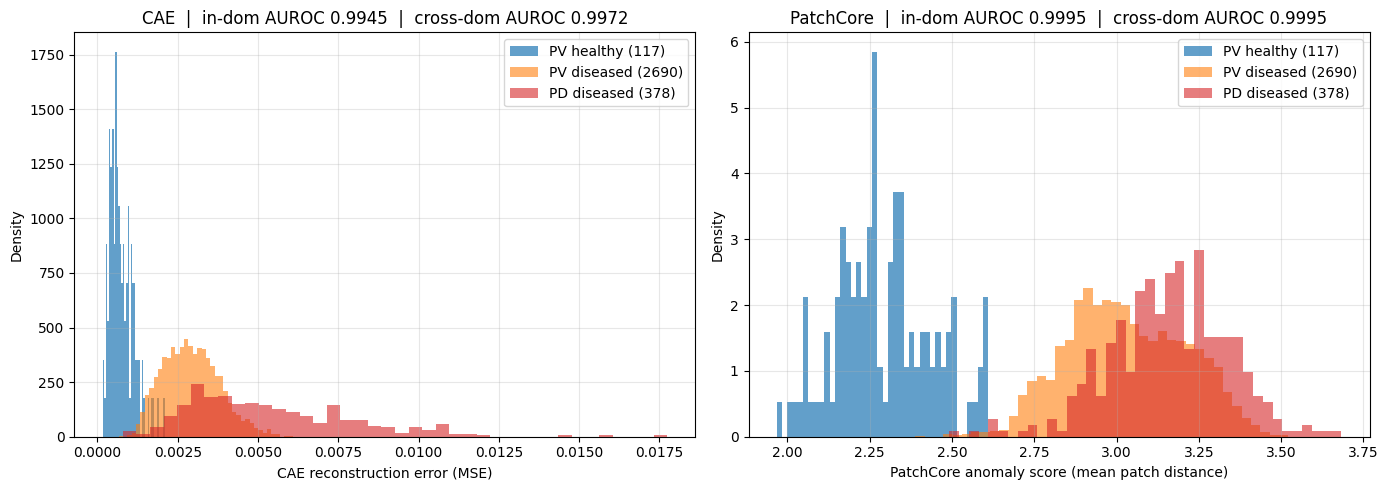

Saved -> /kaggle/working/nb4_score_histograms.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CAE histograms
ax = axes[0]
ax.hist(cae_scores[(cae_classes == "healthy")], bins=40, alpha=0.7,
        label=f"PV healthy ({(cae_classes == 'healthy').sum()})", color="C0", density=True)
ax.hist(cae_scores[(cae_domains == "plantvillage") & (cae_classes != "healthy")], bins=40, alpha=0.6,
        label=f"PV diseased ({((cae_domains == 'plantvillage') & (cae_classes != 'healthy')).sum()})", color="C1", density=True)
ax.hist(cae_scores[cae_domains == "plantdoc"], bins=40, alpha=0.6,
        label=f"PD diseased ({(cae_domains == 'plantdoc').sum()})", color="C3", density=True)
ax.set_xlabel("CAE reconstruction error (MSE)")
ax.set_ylabel("Density")
ax.set_title(f"CAE  |  in-dom AUROC {0.9945:.4f}  |  cross-dom AUROC {0.9972:.4f}")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

# PatchCore histograms
ax = axes[1]
ax.hist(pc_scores_mean[(pc_classes == "healthy")], bins=40, alpha=0.7,
        label=f"PV healthy ({(pc_classes == 'healthy').sum()})", color="C0", density=True)
ax.hist(pc_scores_mean[(pc_domains == "plantvillage") & (pc_classes != "healthy")], bins=40, alpha=0.6,
        label=f"PV diseased ({((pc_domains == 'plantvillage') & (pc_classes != 'healthy')).sum()})", color="C1", density=True)
ax.hist(pc_scores_mean[pc_domains == "plantdoc"], bins=40, alpha=0.6,
        label=f"PD diseased ({(pc_domains == 'plantdoc').sum()})", color="C3", density=True)
ax.set_xlabel("PatchCore anomaly score (mean patch distance)")
ax.set_ylabel("Density")
ax.set_title(f"PatchCore  |  in-dom AUROC {auroc_pv:.4f}  |  cross-dom AUROC {auroc_pd:.4f}")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/nb4_score_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved -> /kaggle/working/nb4_score_histograms.png")

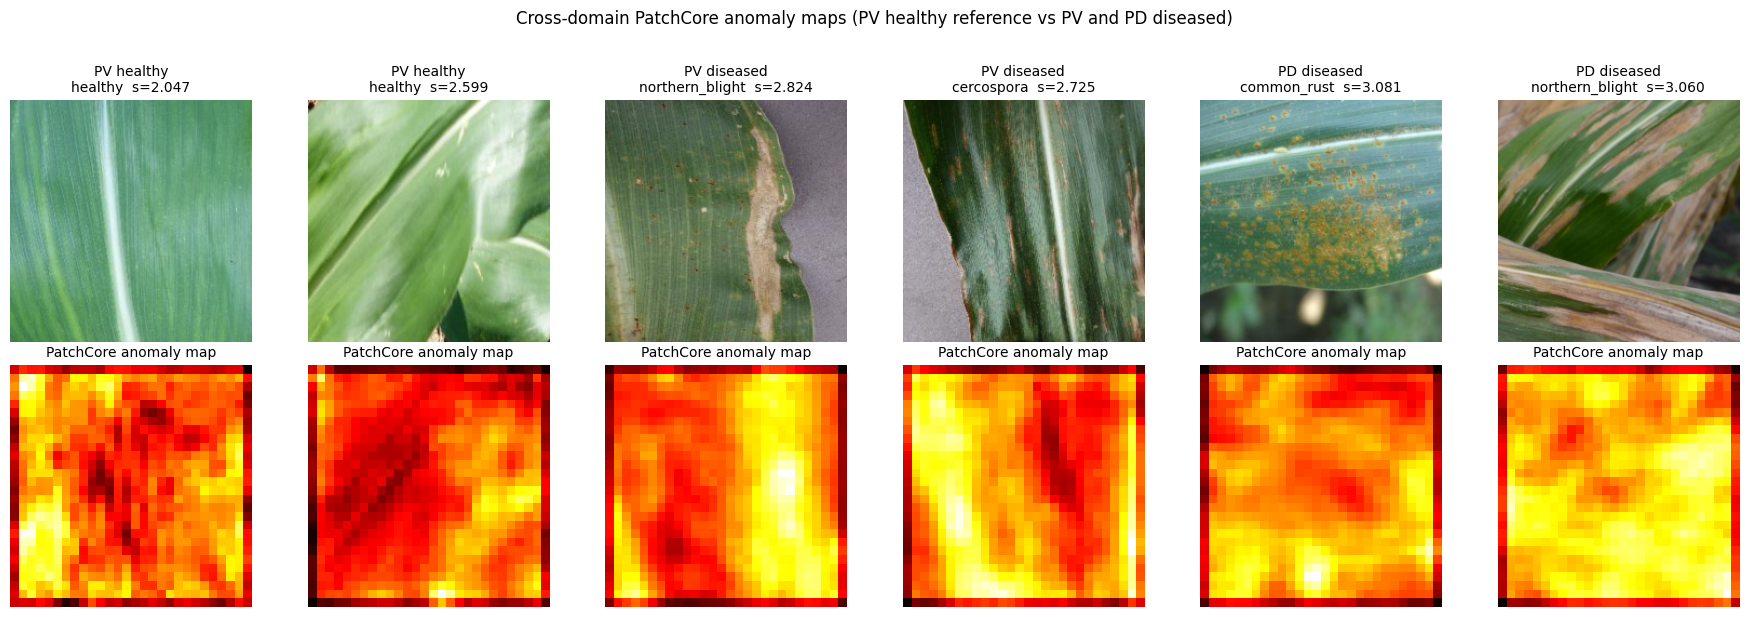

Saved -> /kaggle/working/nb4_anomaly_maps.png


In [17]:
def denormalize(t):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (t.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Pick 2 examples per condition: healthy PV, PV diseased, PD diseased
np.random.seed(42)
test_idx = np.arange(len(pc_test_ds))

healthy_idx = np.random.choice(test_idx[pc_classes == "healthy"], 2, replace=False)
pv_idx      = np.random.choice(test_idx[(pc_domains == "plantvillage") & (pc_classes != "healthy")], 2, replace=False)
pd_idx      = np.random.choice(test_idx[pc_domains == "plantdoc"], 2, replace=False)

picks = list(healthy_idx) + list(pv_idx) + list(pd_idx)
labels = ["PV healthy"]*2 + ["PV diseased"]*2 + ["PD diseased"]*2

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, (idx, lbl) in enumerate(zip(picks, labels)):
    sample = pc_test_ds[idx]
    img = denormalize(sample["image"])
    a_map = pc_maps[idx].numpy()

    axes[0, col].imshow(img)
    axes[0, col].set_title(f"{lbl}\n{sample['class']}  s={pc_scores_mean[idx]:.3f}", fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(a_map, cmap="hot")
    axes[1, col].set_title("PatchCore anomaly map", fontsize=10)
    axes[1, col].axis("off")

plt.suptitle("Cross-domain PatchCore anomaly maps (PV healthy reference vs PV and PD diseased)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/nb4_anomaly_maps.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved -> /kaggle/working/nb4_anomaly_maps.png")


In [18]:
import shutil, zipfile
from IPython.display import FileLink, display

out_dir = Path("/kaggle/working/results_nb4")
out_dir.mkdir(exist_ok=True)

artifacts = [
    "cae_scores.csv",
    "patchcore_scores.csv",
    "manifest.csv",
    "cae_best.pt",
    "nb4_score_histograms.png",
    "nb4_anomaly_maps.png",
]
copied = []
for a in artifacts:
    src = Path(f"/kaggle/working/{a}")
    if src.exists():
        shutil.copy(src, out_dir / a)
        copied.append(a)

# Zip it
zip_path = "/kaggle/working/nb4_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in out_dir.iterdir():
        zf.write(f, arcname=f.name)

print(f"Bundled {len(copied)} artifacts -> {zip_path}\n")
with zipfile.ZipFile(zip_path) as zf:
    for info in zf.infolist():
        mb = info.file_size / 1e6
        print(f"  {info.filename:<32} {mb:>8.2f} MB")

print("\nClick the link below to download the bundle:")
display(FileLink(zip_path))

Bundled 6 artifacts -> /kaggle/working/nb4_artifacts.zip

  cae_scores.csv                       0.62 MB
  nb4_anomaly_maps.png                 0.81 MB
  cae_best.pt                          4.34 MB
  manifest.csv                         0.80 MB
  patchcore_scores.csv                 0.64 MB
  nb4_score_histograms.png             0.07 MB

Click the link below to download the bundle:


/kaggle/working/nb4_artifacts.zip

In [19]:
import base64, zipfile
from pathlib import Path
from IPython.display import HTML, display

# Slim bundle — skip cae_best.pt since NB1's checkpoint is already in the repo
# (NB4's checkpoint is identical anyway: val 0.00086 vs NB1's 0.00090)
slim_zip = "/kaggle/working/nb4_artifacts.zip"

with zipfile.ZipFile(slim_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in [
        "manifest.csv",
        "cae_scores.csv",
        "patchcore_scores.csv",
        "nb4_score_histograms.png",
        "nb4_anomaly_maps.png",
    ]:
        src = Path(f"/kaggle/working/{fname}")
        if src.exists():
            zf.write(src, arcname=fname)

size_mb = Path(slim_zip).stat().st_size / 1e6
print(f"Bundle size: {size_mb:.2f} MB\n")

with zipfile.ZipFile(slim_zip) as zf:
    for info in zf.infolist():
        print(f"  {info.filename:<32} {info.file_size/1024:>8.1f} KB")

# Encode as data URL
with open(slim_zip, "rb") as f:
    data = base64.b64encode(f.read()).decode()

html = f"""
<div style="margin-top:20px;">
  <a download="nb4_artifacts.zip" href="data:application/zip;base64,{data}">
    <button style="padding:12px 24px; font-size:14px; background:#0066cc; color:white;
                   border:none; border-radius:4px; cursor:pointer;">
      Download nb4_artifacts.zip ({size_mb:.2f} MB)
    </button>
  </a>
</div>
"""
display(HTML(html))

Bundle size: 1.09 MB

  manifest.csv                        784.5 KB
  cae_scores.csv                      605.8 KB
  patchcore_scores.csv                626.3 KB
  nb4_score_histograms.png             67.2 KB
  nb4_anomaly_maps.png                792.6 KB
